# Classification Experiment

This notebook demonstrates the project workflow: load data, preprocess features, train a model, and evaluate predictions. Reusable code lives in `src/interview_project`.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

from interview_project.evaluation import classification_metrics
from interview_project.modeling import build_logistic_classifier, fit_classifier
from interview_project.preprocessing import make_preprocessor, split_features_target

In [3]:
iris = load_iris(as_frame=True)
data = iris.frame.rename(columns={"target": "species"})
data["species"] = data["species"].map(dict(enumerate(iris.target_names)))

data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Prepare the data

The preprocessing module keeps the split and feature transformations outside the notebook so they can be reused and tested.

In [4]:
X_train, X_test, y_train, y_test = split_features_target(
    data,
    target="species",
    test_size=0.2,
    random_state=42,
)

preprocessor = make_preprocessor(numeric_features=list(X_train.columns))
model = build_logistic_classifier(preprocessor)
model = fit_classifier(model, X_train, y_train)

## Evaluate the model

In [5]:
metrics = classification_metrics(model, X_test, y_test)
print(f"Accuracy: {metrics['accuracy']:.3f}")
pd.DataFrame(metrics["classification_report"]).T.round(3)

Accuracy: 0.933


,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,10.000
versicolor,0.900,0.900,0.900,10.000
virginica,0.900,0.900,0.900,10.000
accuracy,0.933,0.933,0.933,0.933
macro avg,0.933,0.933,0.933,30.000
weighted avg,0.933,0.933,0.933,30.000


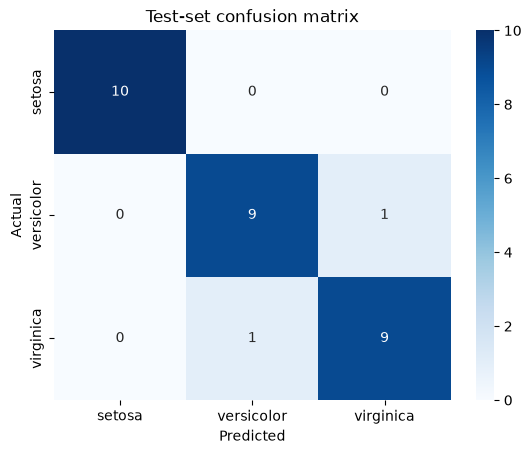

In [6]:
confusion = pd.DataFrame(
    metrics["confusion_matrix"],
    index=iris.target_names,
    columns=iris.target_names,
)
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test-set confusion matrix")
plt.show()